# Decision Trees and Hyperparameter Tuning
This notebook covers the theory and implementation of Decision Trees for classification and regression, along with techniques for hyperparameter tuning to improve model performance.


## Introduction
The decision tree algorithm is a hierarchical tree-based algorithm that is used to classify or predict outcomes based on a set of rules.
Decision Trees are a type of **supervised learning algorithm** used for both classification and regression tasks. They work by **splitting the dataset into subsets** based on the value of input features, forming a tree-like structure. The resulting tree is a set of decision rules that can be used to make predictions or classify new data.

Key characteristics:
- Easy to understand and interpret.
- Can handle both numerical and categorical data.
- Sensitive to overfitting if the tree grows too deep.


## Feature Importance
Decision Trees can provide **feature importance**, indicating how useful each feature was in predicting the target.

- A feature is considered important if it helps the tree split the data into groups that are more **Pure**(target is more consistent in each group).
- The importance score shows how much each feature contributed to reducing mistakes in the tree.
- Useful for:
  - Understanding the data.
  - Feature selection for other models.

## Decision Tree Basics

A Decision Tree consists of:
- **Root Node**: The top node representing the best feature to split the data (no incoming edge, zero or more outgoing edge).
- **Decision Nodes**: Nodes where the data is further split based on feature values.
- **Internal Nodes** : Nodes exactly one incoming edge and two or more outgoing edge.

- **Leaf Nodes (Terminal Nodes)**: Nodes representing the output or target class(exactly one incoming edge, no outgoing edge).
- **Branches/Edges**: Value of attribute.
- **Examples:** Binary Tree, Multiple Branch Tree

# Reference 
https://www.tutorialspoint.com/machine_learning/machine_learning_decision_tree_algorithm.htm

# Example
 
  a binary tree for predicting whether a person is fit or unfit providing various information like age, eating habits and exercise habits, 
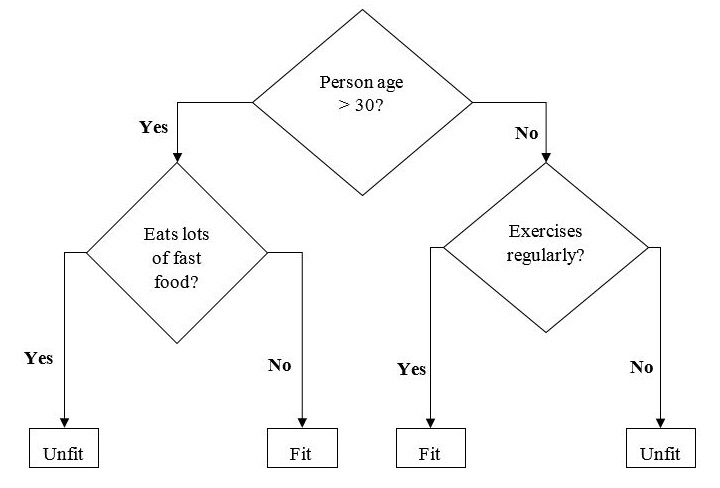

## Types of Decision Tree Algorithm :
Classification Tree − A classification tree is used to classify data into different classes or categories. It works by splitting the data into subsets based on the values of the input features and assigning each subset to a different class.

Regression Tree − A regression tree is used to predict numerical values or continuous variables. It works by splitting the data into subsets based on the values of the input features and assigning each subset a numerical value.


The Decision Tree algorithm works by selecting the best feature to split the data at each node. The best feature is the one that provides the most information gain or the most reduction in entropy. Information gain is a measure of the amount of information gained by splitting the data at a particular feature, while entropy is a measure of the randomness or disorder in the data. The algorithm uses these measures to determine the best feature to split the data at each node.

## How Does a Decision Tree Split?  

To decide the **best split**, a decision tree measures how "pure" or "impure" the data is at each node.  
The goal is to split the dataset into **purer subsets**:  
- "Pure" = node contains mostly one class (classification) or has low variance (regression).  
- The choice of *criterion* (e.g., **Gini**, **Entropy**) determines how impurity is measured.  

---

### 1. Entropy (Impurity Measure from Information Theory)  

Entropy measures the **uncertainty** (or disorder) in the data:  

$$
Entropy(S) = -\sum_{i=1}^{C} p_i \log_2(p_i)
$$

Where:  
- \(C\) = number of classes.  
- \(p_i\) = proportion of samples belonging to class \(i\).  

**Interpretation:**  
- \(Entropy = 0\) → perfectly pure node (all samples same class).  
- Higher entropy → more mixed classes.  

---

### 2. Information Gain (Splitting Rule when using Entropy)  

When using `criterion="entropy"`, the tree evaluates splits based on **Information Gain (IG)**:  

$$
IG = Entropy(parent) - \sum_{k=1}^{m} \frac{n_k}{n} \cdot Entropy(child_k)
$$  

Where:  
- Parent = node before split.  
- Children = nodes after split.  
- \(n_k\) = samples in child \(k\), \(n\) = total samples.  

**Key point:**  
- Don’t set “Information Gain” directly.  
- It’s the **reduction in entropy** used internally when the criterion is `"entropy"`.  

---

### 3. Gini Impurity (Default in scikit-learn)  

Gini measures impurity as the probability of misclassification if a sample is chosen randomly:  

$$
Gini(S) = 1 - \sum_{i=1}^{C} p_i^2
$$ 

**Interpretation:**  
- \(Gini = 0\) → pure node (all one class).  
- Higher Gini → more mixed.  

**Examples:**  
- All "Yes" → Gini = 0.  
- 50% "Yes", 50% "No" → Gini = 0.5 (max impurity for 2 classes).  

When using `criterion="gini"`, the tree chooses splits that **maximize the reduction in Gini impurity** .  

---

### 4. Choosing Between Entropy and Gini  

- **Entropy + Information Gain** → more theory-heavy, interprets disorder using logs, slightly slower.  
- **Gini Impurity** → computationally simpler, usually very similar results, default in scikit-learn.  

**In practice:**  
- If speed matters → use **Gini**.  
- If you want a clear link to information theory → use **Entropy**.  
- Results are often nearly identical.  

---

## Summary  

| Criterion (scikit-learn) | What is measured?   | How splits are chosen?            |
|---------------------------|---------------------|-----------------------------------|
| **gini** (default)        | Gini Impurity       | Maximize reduction in Gini impurity |
| **entropy**               | Entropy             | Maximize Information Gain (reduction in entropy) |

 **Important:** Information Gain is *not* a separate criterion.  
 It is the **splitting rule derived from entropy**.  


## Advantages
- Easy to understand and visualize.
- Requires little data preprocessing.
- Can handle both categorical and numerical data.
- Non-parametric (no assumptions about data distribution).

## Disadvantages
- Can easily overfit if tree is too deep.
- Sensitive to small changes in data (unstable).
- May be biased if some classes dominate.


## Decision Tree Visual Explanantion
https://mlu-explain.github.io/decision-tree/

In [198]:
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Dataset : Loan Approval Prediction 

- https://www.kaggle.com/code/ajaymanwani/loan-approval-prediction

- Problem : Company wants to automate the loan eligibility process based on customer details. Features are Gender, Marital Status, Education, Number of Dependents, Income, Loan Amount, Credit History and others. Its a Classification Problem - Target Feature is Loan Status

## Understand the Dataset

Columns in loan datasets:

- **Identifiers:** `Loan_ID`
- **Categorical:** `Gender`, `Married`, `Dependents`, `Education`, `Self_Employed`, `Credit_History`, `Property_Area`
- **Numeric:** `ApplicantIncome`, `CoapplicantIncome`, `LoanAmount`, `Loan_Amount_Term`
- **Target:** `Loan_Status` - {`Y`, `N`}

**We’ll check:**
1. **Shape** and **column names**
2. **Data types** (numeric vs categorical)
3. **Missing values**


In [199]:
# Loan dataset
df = pd.read_csv('loan_data_set.csv')
df.shape

(614, 13)

In [200]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [201]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [202]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

## Data Preprocessing

In [203]:
df = df.drop(['Loan_ID'], axis = 1)


In [204]:
# Fill categorical columns with mode
categorical_cols = ['Gender','Married','Dependents','Self_Employed','Credit_History','Loan_Amount_Term']
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Fill numerical column with mean
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].mean())
df.isnull().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [205]:
# one hot encoding - transform categorical columns to numerical columns - for ML algorithms to do a better prediction
df = pd.get_dummies(df, drop_first=True) # get_dummies convert the categorical columns to numerical columns in binary format, drop_first=True to avoid dummy variable trap 
df.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban,Loan_Status_Y
0,5849,0.0,146.412162,360.0,1.0,True,False,False,False,False,False,False,False,True,True
1,4583,1508.0,128.000000,360.0,1.0,True,True,True,False,False,False,False,False,False,False
2,3000,0.0,66.000000,360.0,1.0,True,True,False,False,False,False,True,False,True,True
3,2583,2358.0,120.000000,360.0,1.0,True,True,False,False,False,True,False,False,True,True
4,6000,0.0,141.000000,360.0,1.0,True,False,False,False,False,False,False,False,True,True


In [206]:
# Feature Seperation
X = df.drop('Loan_Status_Y', axis=1)
y = df['Loan_Status_Y']

# Test - train Split

When building a Machine Learning model, we need to evaluate how well it performs on **unseen data**.  
If we train and test on the same dataset, the model might **memorize** (overfit) instead of generalizing.

To avoid this, we divide the dataset into two (or three) parts:

- **Training Set**  
  Used to **fit/train** the model.  
  The model learns the relationship between features (X) and the target (y).

- **Testing Set**  
  Used to **evaluate** the trained model on unseen data.  
  This shows how well the model generalizes.

- (Optional) **Validation Set**  
  Sometimes, we further split the training set into training + validation.  
  The validation set helps in **hyperparameter tuning** (choosing best tree depth, criterion, etc.), while the test set is only used for **final evaluation**.


### `train_test_split` in Scikit-Learn: Scikit-learn provides the function
###  Simple Train-Test Split
- Uses `train_test_split()` from sklearn.  
- Data is randomly divided into training and testing sets.  
- Example: `test_size=0.3 → 70% train, 30% test.  
- Good for balanced datasets.  
- Risk: if classes are imbalanced, the split may not represent the true distribution.
### Different approches of train_test_split:
https://share.google/yJJjYbwEfH1nDddHN


In [207]:
from sklearn.model_selection import train_test_split
# Test - train Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## Choosing the Right Evaluation Metric  

### 1. Accuracy  
$$
Accuracy = \frac{TP + TN}{TP + TN + FP + FN}
$$  

- **What it means:** Proportion of all correct predictions.  
- **When to use:**  
  - Dataset is **balanced** (classes are almost equal).  
  - Example: If predicting loan approval with 50% "Approved" and 50% "Not Approved," accuracy works fine.  

---

### 2. Precision  
$$
Precision = \frac{TP}{TP + FP}
$$  

- **What it means:** Out of all applicants predicted as *Approved*, how many were actually approved?  
- **When to use:**  
  - When the **cost of a False Positive is high**.  
  - Example: If wrongly approving a loan is very risky for the bank, we want high Precision.  

---

### 3. Recall (Sensitivity / True Positive Rate)  
$$
Recall = \frac{TP}{TP + FN}
$$  

- **What it means:** Out of all applicants who *should be approved*, how many did we correctly predict?  
- **When to use:**  
  - When the **cost of a False Negative is high**.  
  - Example: If rejecting a genuine applicant is very bad for the bank (customer dissatisfaction), we want high Recall.  

---

### 4. F1-Score  
$$
F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}
$$  

- **What it means:** Harmonic mean of Precision and Recall.  
- **When to use:**  
  - When the dataset is **imbalanced** and we need a balance between Precision & Recall.  
  - Example: If only 20% of applicants are approved, F1-score is better than Accuracy.  

---

### Example (Confusion Matrix)  
<img src="confusion-matrix.webp" width="400" height="250"/>

Suppose we have 100 loan applicants:  
- 60 actually approved, 40 actually not approved.  

The model predictions:  
- True Positives (TP) = 50 (correctly predicted approved)  
- False Positives (FP) = 10 (wrongly predicted approved)  
- True Negatives (TN) = 30 (correctly predicted not approved)  
- False Negatives (FN) = 10 (missed approvals)  

Metrics:  
- Accuracy = (50 + 30) / 100 = **80%**  
- Precision = 50 / (50 + 10) = **83%**  
- Recall = 50 / (50 + 10) = **83%**  
- F1-score = 2 × (0.83 × 0.83) / (0.83 + 0.83) = **83%**  

---

 **Takeaway:**  
- Use **Accuracy** for balanced datasets.  
- Use **Precision** when False Positives are costly.  
- Use **Recall** when False Negatives are costly.  
- Use **F1-score** when the dataset is imbalanced and you want a trade-off.  


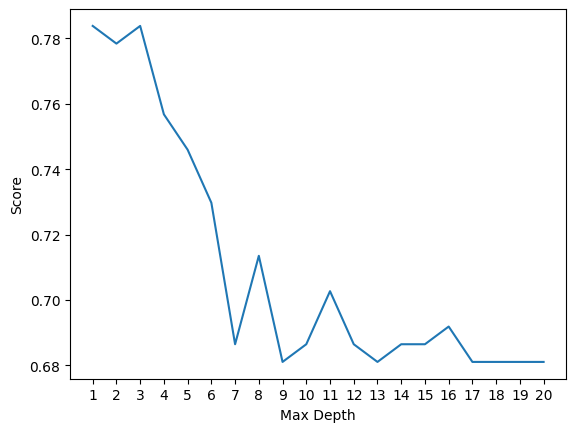

Decision Tree Accuracy: 78.38%


In [208]:
import numpy as np

scoreListDT = []
for i in range(1,21):
    DTclassifier = DecisionTreeClassifier(max_depth=i, random_state=42)
    DTclassifier.fit(X_train, y_train)
    scoreListDT.append(DTclassifier.score(X_test, y_test))

plt.plot(range(1,21), scoreListDT)
plt.xticks(np.arange(1,21,1))
plt.xlabel("Max Depth")
plt.ylabel("Score")
plt.show()
DTAcc = max(scoreListDT)
print("Decision Tree Accuracy: {:.2f}%".format(DTAcc*100))


In [209]:
best_acc = max(scoreListDT)
best_depth = scoreListDT.index(best_acc) + 1  # +1 because index starts at 0
print(f"Best Accuracy: {best_acc*100:.2f}% at max_depth = {best_depth}")


Best Accuracy: 78.38% at max_depth = 1


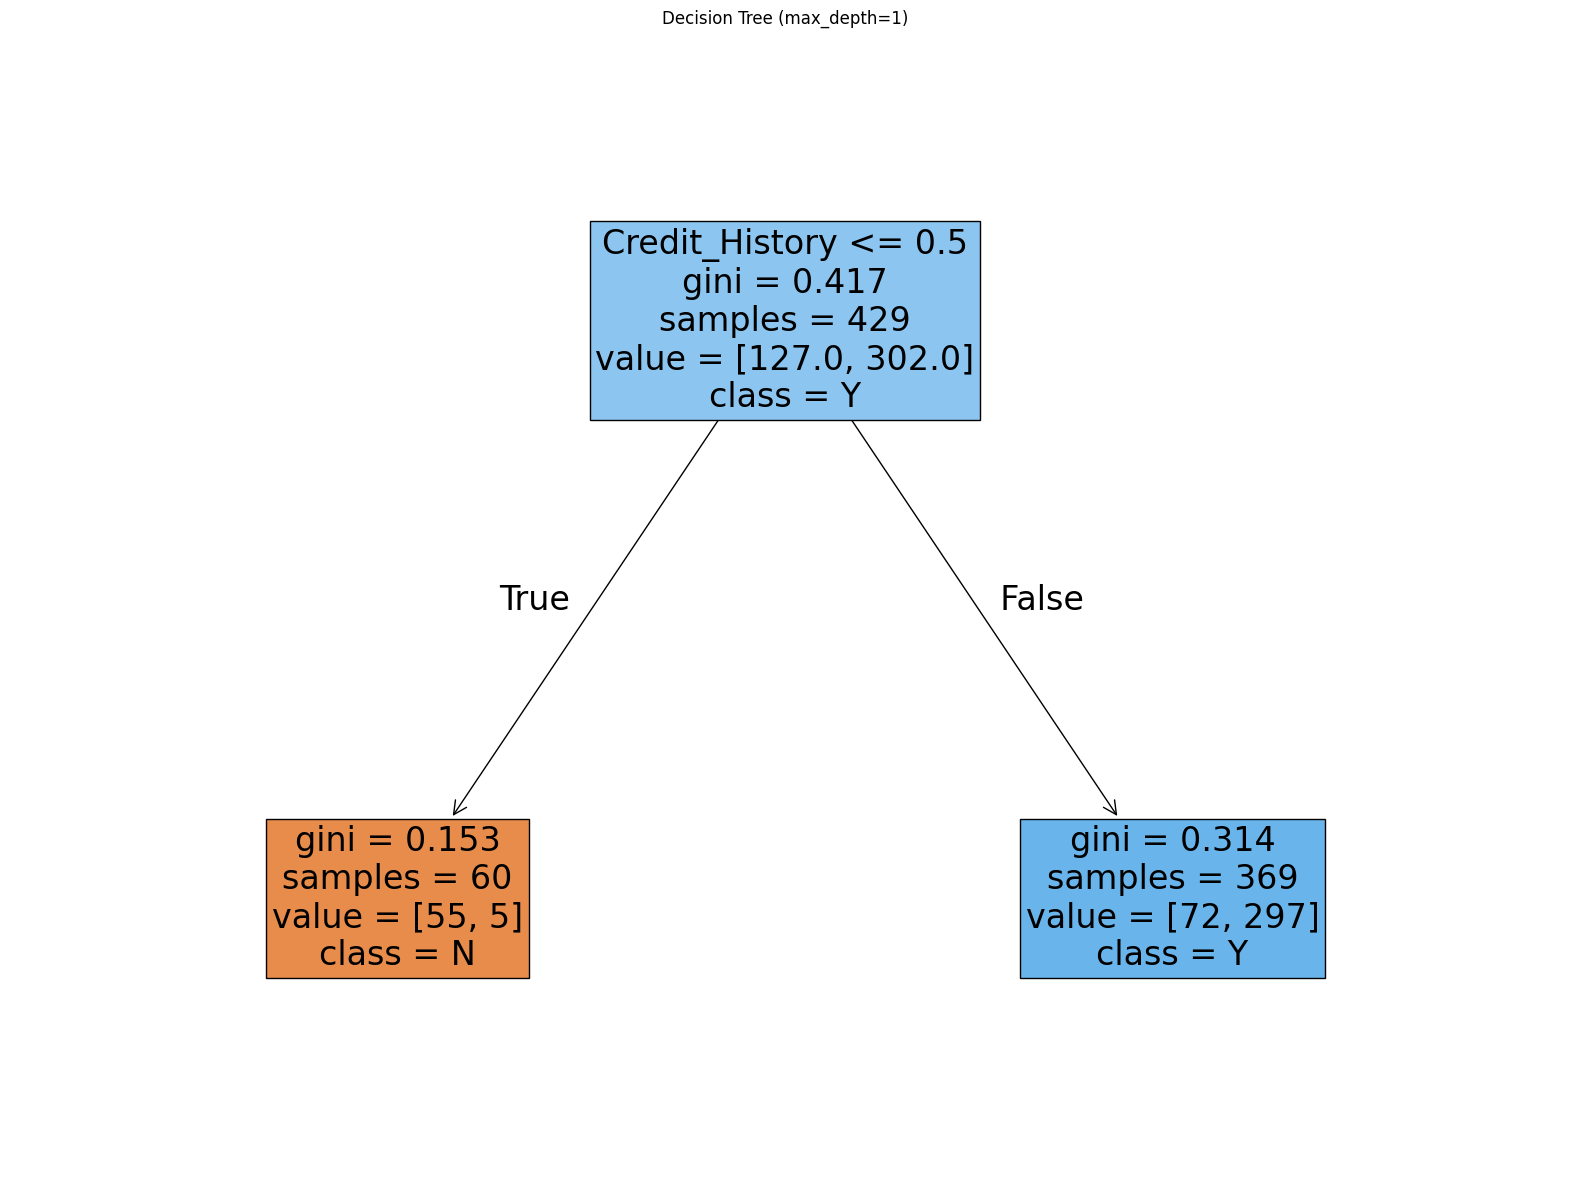

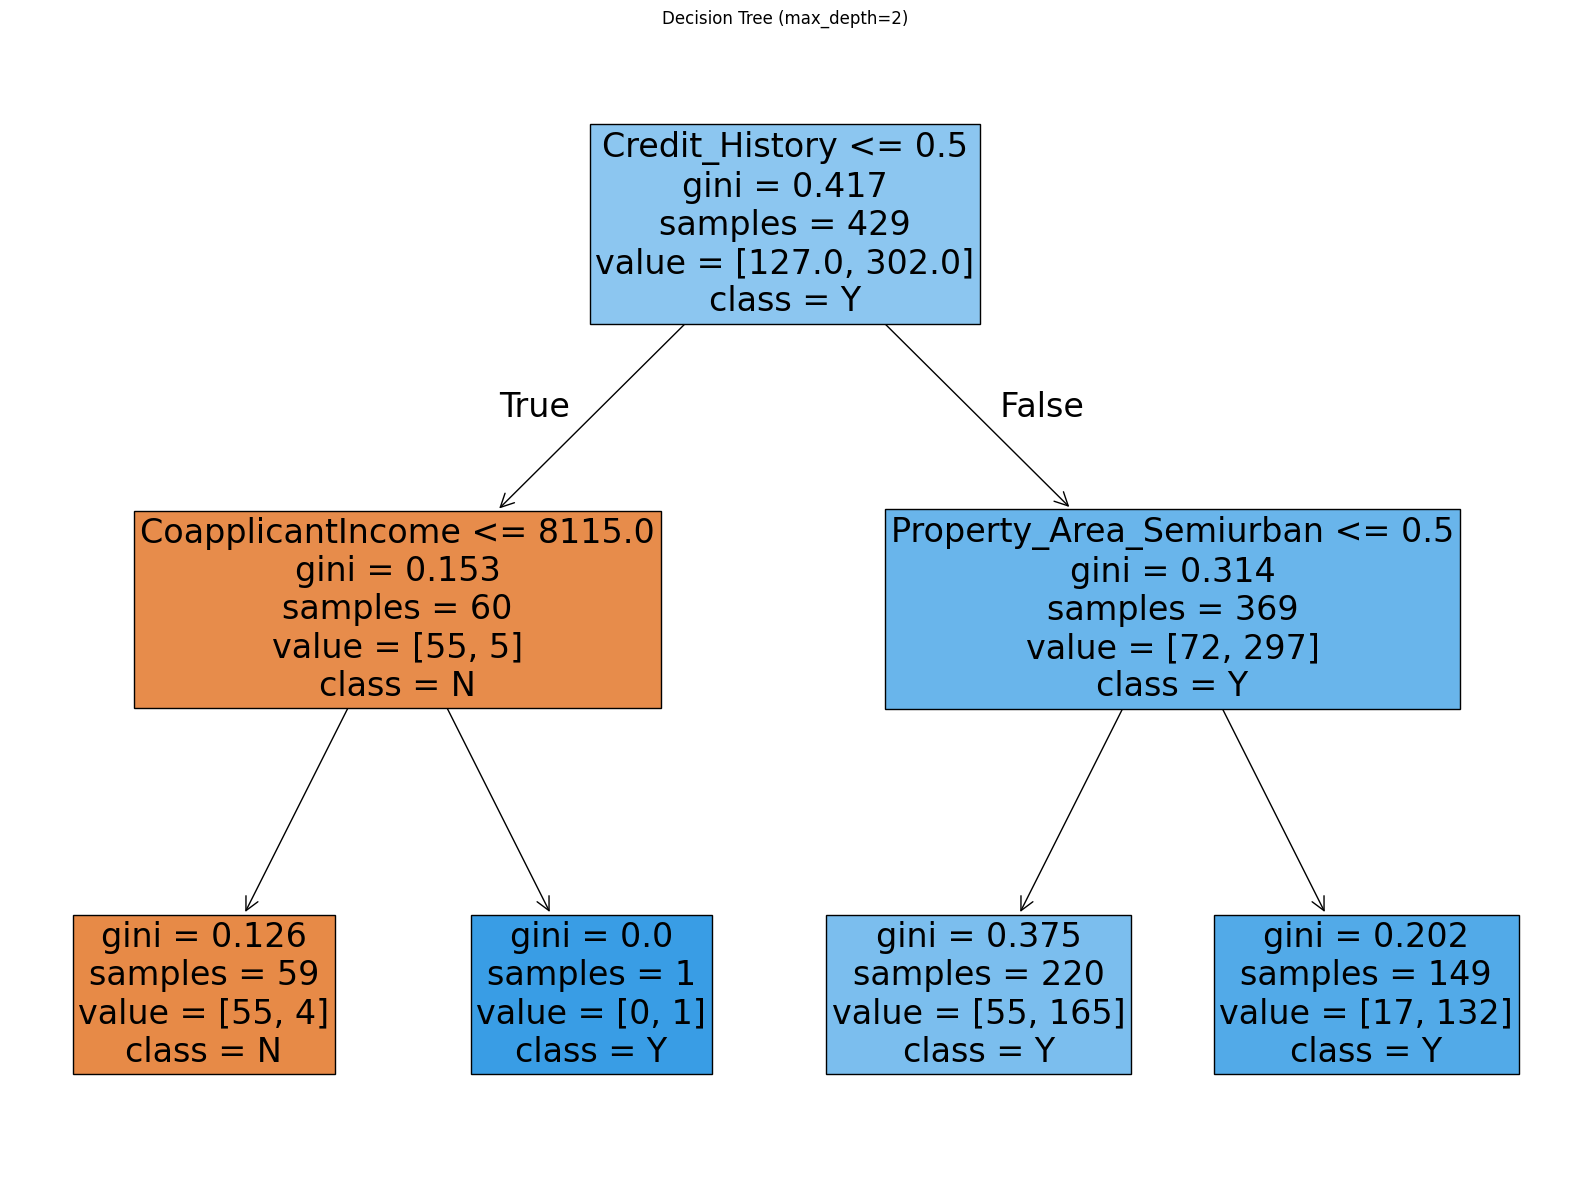

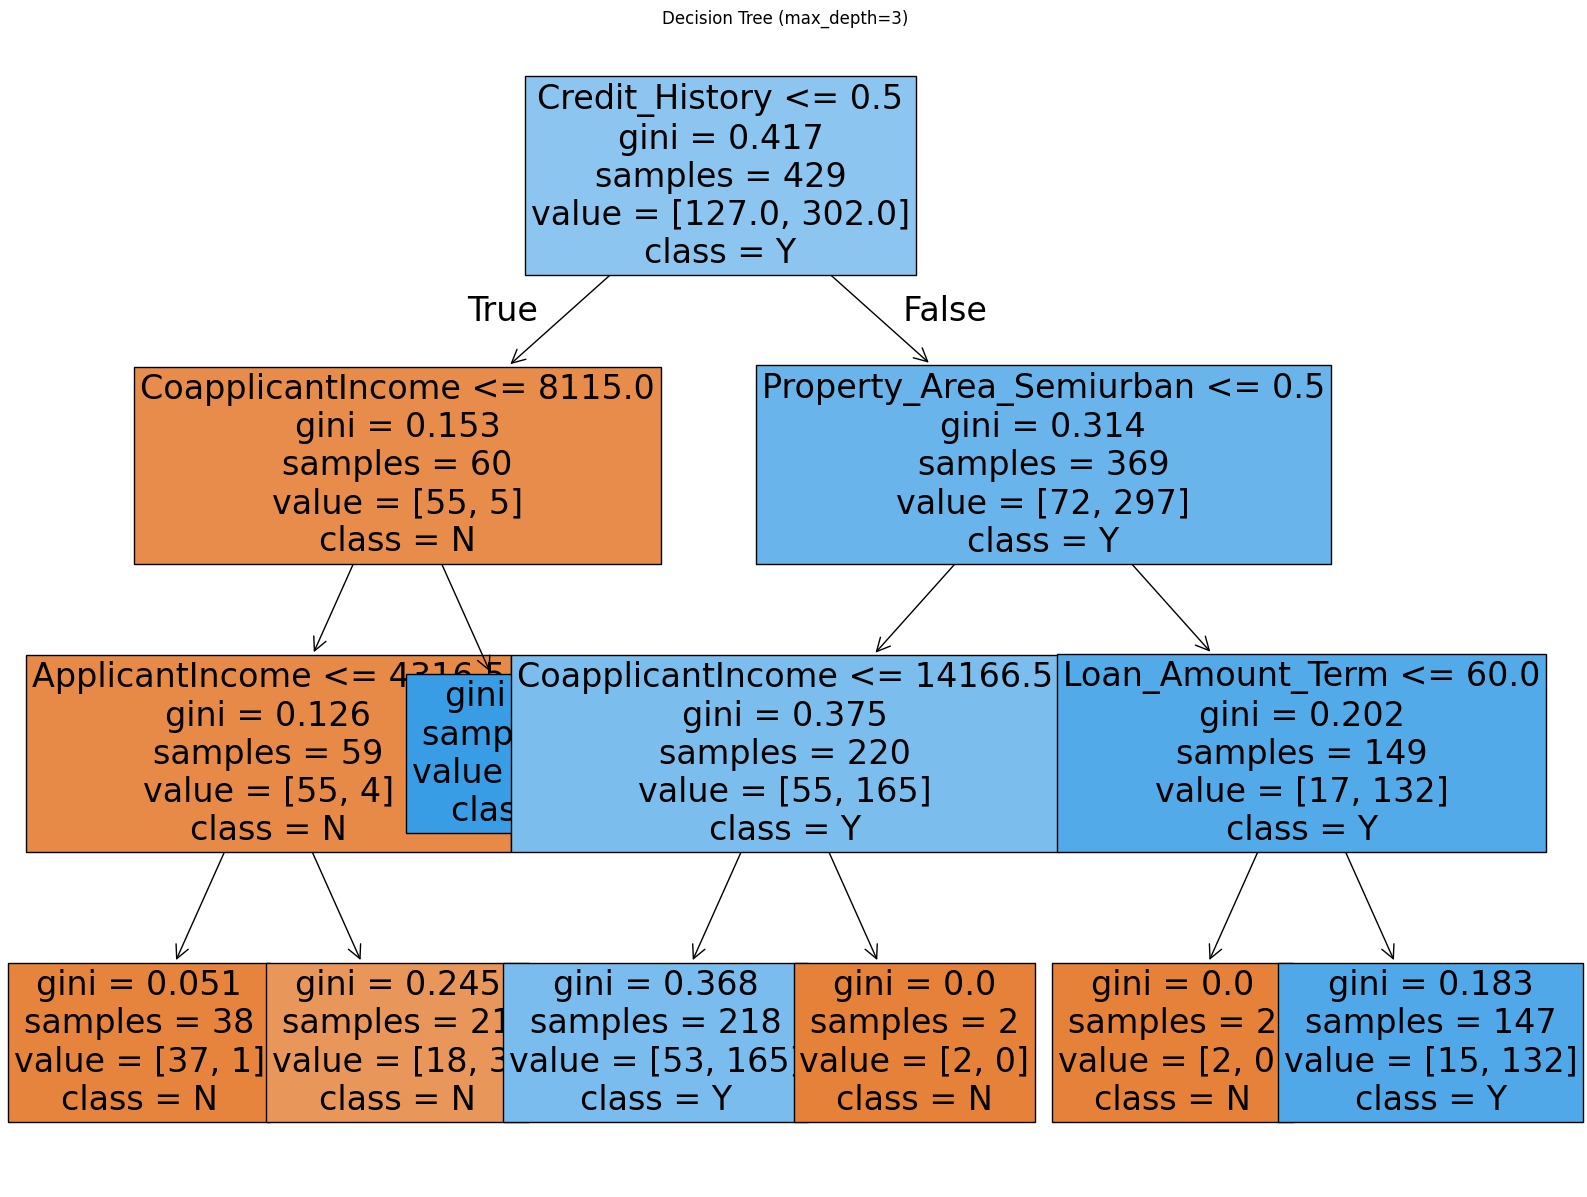

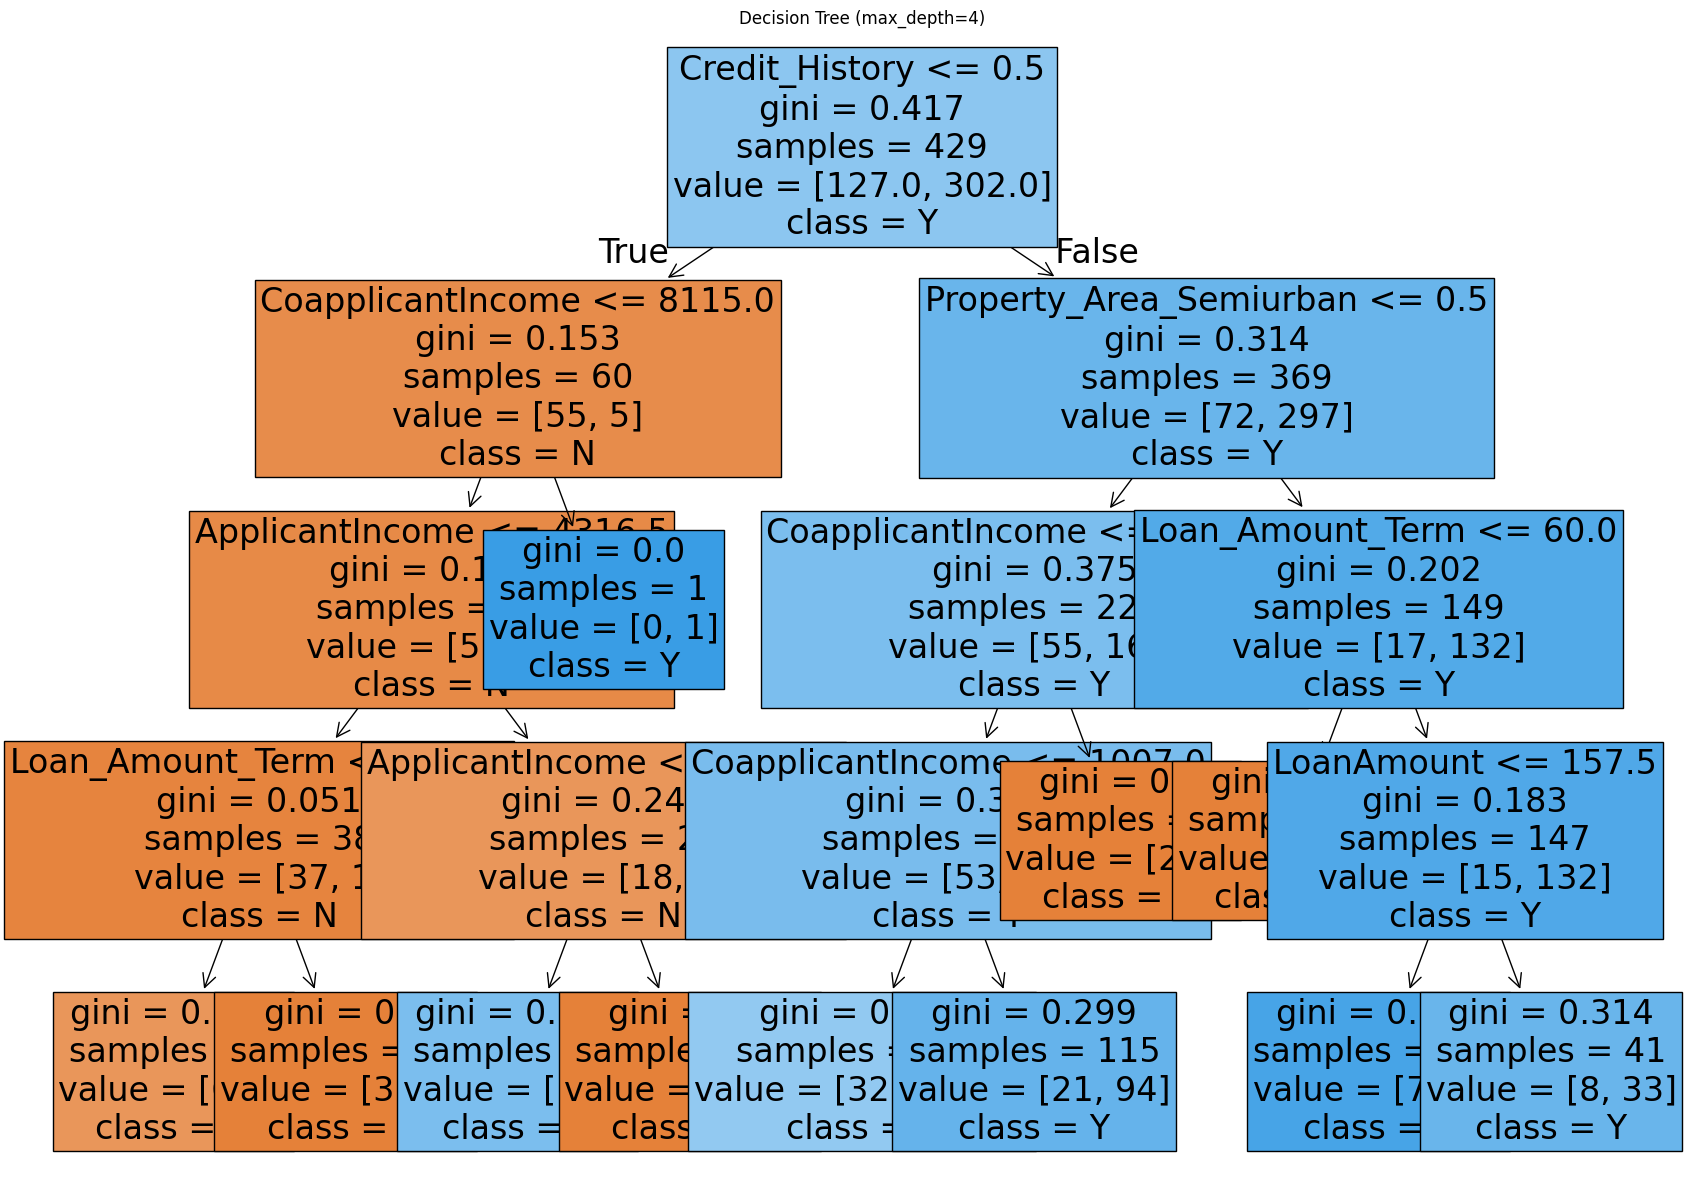

In [210]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

depths_to_plot = [1, 2, 3, 4]

for d in depths_to_plot:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    
    plt.figure(figsize=(20, 15))
    plot_tree(clf, filled=True, fontsize=24, feature_names=X.columns, class_names=['N', 'Y'])
    plt.title(f"Decision Tree (max_depth={d})")
    plt.show()


In [211]:
# feature importance 
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)
importances = clf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
print(feature_importance_df)


                    Feature  Importance
4            Credit_History    0.832517
1         CoapplicantIncome    0.061654
12  Property_Area_Semiurban    0.050840
3          Loan_Amount_Term    0.049297
0           ApplicantIncome    0.005692
2                LoanAmount    0.000000
5               Gender_Male    0.000000
6               Married_Yes    0.000000
8              Dependents_2    0.000000
7              Dependents_1    0.000000
9             Dependents_3+    0.000000
10   Education_Not Graduate    0.000000
11        Self_Employed_Yes    0.000000
13      Property_Area_Urban    0.000000


In [212]:

# Accuracy and Classification Report
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7837837837837838
              precision    recall  f1-score   support

       False       0.93      0.42      0.57        65
        True       0.76      0.98      0.86       120

    accuracy                           0.78       185
   macro avg       0.84      0.70      0.71       185
weighted avg       0.82      0.78      0.76       185



<Axes: >

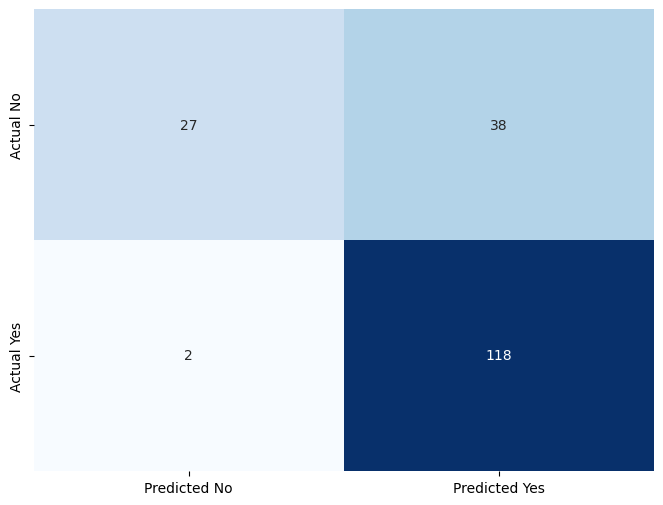

In [213]:
# Plot confusion matrix with labels
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted No', 'Predicted Yes'],
            yticklabels=['Actual No', 'Actual Yes'])

- **TN (27)**: Correctly predicted **No** (rejected) loans.
- **FP (38)**: Predicted **Yes** (approved) but actually **No** → **risky approvals**.
- **FN (2)**: Predicted **No** but actually **Yes** → **missed good customers**.
- **TP (118)**: Correctly predicted **Yes** (approved) loans.


In [214]:
# feature importance  -  depth to 5
clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)
importances = clf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
print(feature_importance_df)
# Accuracy and Classification Report
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

                    Feature  Importance
4            Credit_History    0.659505
0           ApplicantIncome    0.147668
1         CoapplicantIncome    0.070717
3          Loan_Amount_Term    0.051335
12  Property_Area_Semiurban    0.040275
11        Self_Employed_Yes    0.018409
2                LoanAmount    0.012092
5               Gender_Male    0.000000
6               Married_Yes    0.000000
7              Dependents_1    0.000000
9             Dependents_3+    0.000000
8              Dependents_2    0.000000
10   Education_Not Graduate    0.000000
13      Property_Area_Urban    0.000000
Accuracy: 0.745945945945946
              precision    recall  f1-score   support

       False       0.85      0.34      0.48        65
        True       0.73      0.97      0.83       120

    accuracy                           0.75       185
   macro avg       0.79      0.65      0.66       185
weighted avg       0.77      0.75      0.71       185



## Interpretation  
 
- As we increase the depth of the tree, the model starts to **overfit** the training data.  
- Overfitting means the tree is memorizing details from the training set, which causes the **accuracy on test data to decrease**.  
- A shallow tree (small depth) may underfit, but too deep a tree will almost always overfit.  


## Hyperparameter Tuning

Hyperparameters are settings that control the model's learning process, unlike parameters which are learned from data.Instead of guessing values, we use **search methods** to find the best combination.

### Common Hyperparameters in Decision Trees:
- `max_depth`: Maximum depth of the tree. Limits overfitting.
- `min_samples_split`: Minimum number of samples required to split a node.
- `min_samples_leaf`: Minimum number of samples required at a leaf node.
- `max_features`: Maximum number of features considered for a split.
- `criterion`: Measure to evaluate splits (`gini` or `entropy` for classification, `mse` for regression).
- `ccp_alpha`: Complexity parameter for minimal cost-complexity pruning.

### Why Tune Hyperparameters?
- **Prevent overfitting**: Deep trees may memorize training data.
- **Prevent underfitting**: Shallow trees may not capture patterns.
- **Improve generalization**: Achieve better performance on unseen data.

### Hyperparameter Tuning Techniques:
1. **Grid Search**: Tries all possible combinations of hyperparameters.
-  **Pros**: Guaranteed to find the best parameters **within the grid**.
-  **Cons**: Expensive if search space is large.
2. **Random Search**: Randomly samples hyperparameter combinations (faster for large search spaces).It selects a **fixed number of random combinations** from the parameter space.
- **Pros**: Much faster on large/continuous spaces. Can still find very good solutions.
- **Cons**: Not guaranteed to find the absolute best.



### Comparison
- **Grid Search** is exhaustive and safe for small parameter grids.  
- **Randomized Search** is efficient and better for larger ranges.  
- In practice, we often start with **Randomized Search** (broad exploration), then refine with **Grid Search** (fine-tuning).


## Interpretation
- when max_depth is high its training accuracy is high so its observe that decision tree easily overfit the data

In [215]:
from sklearn.model_selection import GridSearchCV

param = {
    "max_depth": [1, 3, 5, 7],
    "criterion": ["gini", "entropy"],
    "min_samples_split": [ 2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_leaf_nodes": [None, 5, 10, 20], 
    
    
}
## Grid Search
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print("Best GridSearch Parameters:", grid_search.best_params_)
print("Best GridSearch Accuracy:", grid_search.best_score_)


Best GridSearch Parameters: {'criterion': 'gini', 'max_depth': 1, 'max_leaf_nodes': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best GridSearch Accuracy: 0.8204651162790698


In [216]:
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_distributions=param,
    n_iter=10,            # try 50 random combinations
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best RandomSearch Parameters:", random_search.best_params_)
print("Best RandomSearch Accuracy:", random_search.best_score_)

Best RandomSearch Parameters: {'min_samples_split': 5, 'min_samples_leaf': 2, 'max_leaf_nodes': 5, 'max_depth': 1, 'criterion': 'entropy'}
Best RandomSearch Accuracy: 0.8204651162790698


# Different ways to visualize tree
- https://mljar.com/blog/visualize-decision-tree/

In [217]:
# Use None for max_depth and max_leaf_nodes to let the tree grow 
import sklearn.tree as tree
clf = DecisionTreeClassifier(
    max_depth=3,
    max_leaf_nodes=None,
    random_state=42
)
clf.fit(X_train, y_train)

print(tree.export_text(clf, feature_names=list(X.columns)))

|--- Credit_History <= 0.50
|   |--- CoapplicantIncome <= 8115.00
|   |   |--- ApplicantIncome <= 4316.50
|   |   |   |--- class: False
|   |   |--- ApplicantIncome >  4316.50
|   |   |   |--- class: False
|   |--- CoapplicantIncome >  8115.00
|   |   |--- class: True
|--- Credit_History >  0.50
|   |--- Property_Area_Semiurban <= 0.50
|   |   |--- CoapplicantIncome <= 14166.50
|   |   |   |--- class: True
|   |   |--- CoapplicantIncome >  14166.50
|   |   |   |--- class: False
|   |--- Property_Area_Semiurban >  0.50
|   |   |--- Loan_Amount_Term <= 60.00
|   |   |   |--- class: False
|   |   |--- Loan_Amount_Term >  60.00
|   |   |   |--- class: True



In [218]:
from sklearn import tree
text_representation = tree.export_text(grid_search.best_estimator_, feature_names=list(X.columns))
print(text_representation)

|--- Credit_History <= 0.50
|   |--- class: False
|--- Credit_History >  0.50
|   |--- class: True



Text(0.5, 1.0, 'Decision Tree (Best Estimator from GridSearchCV)')

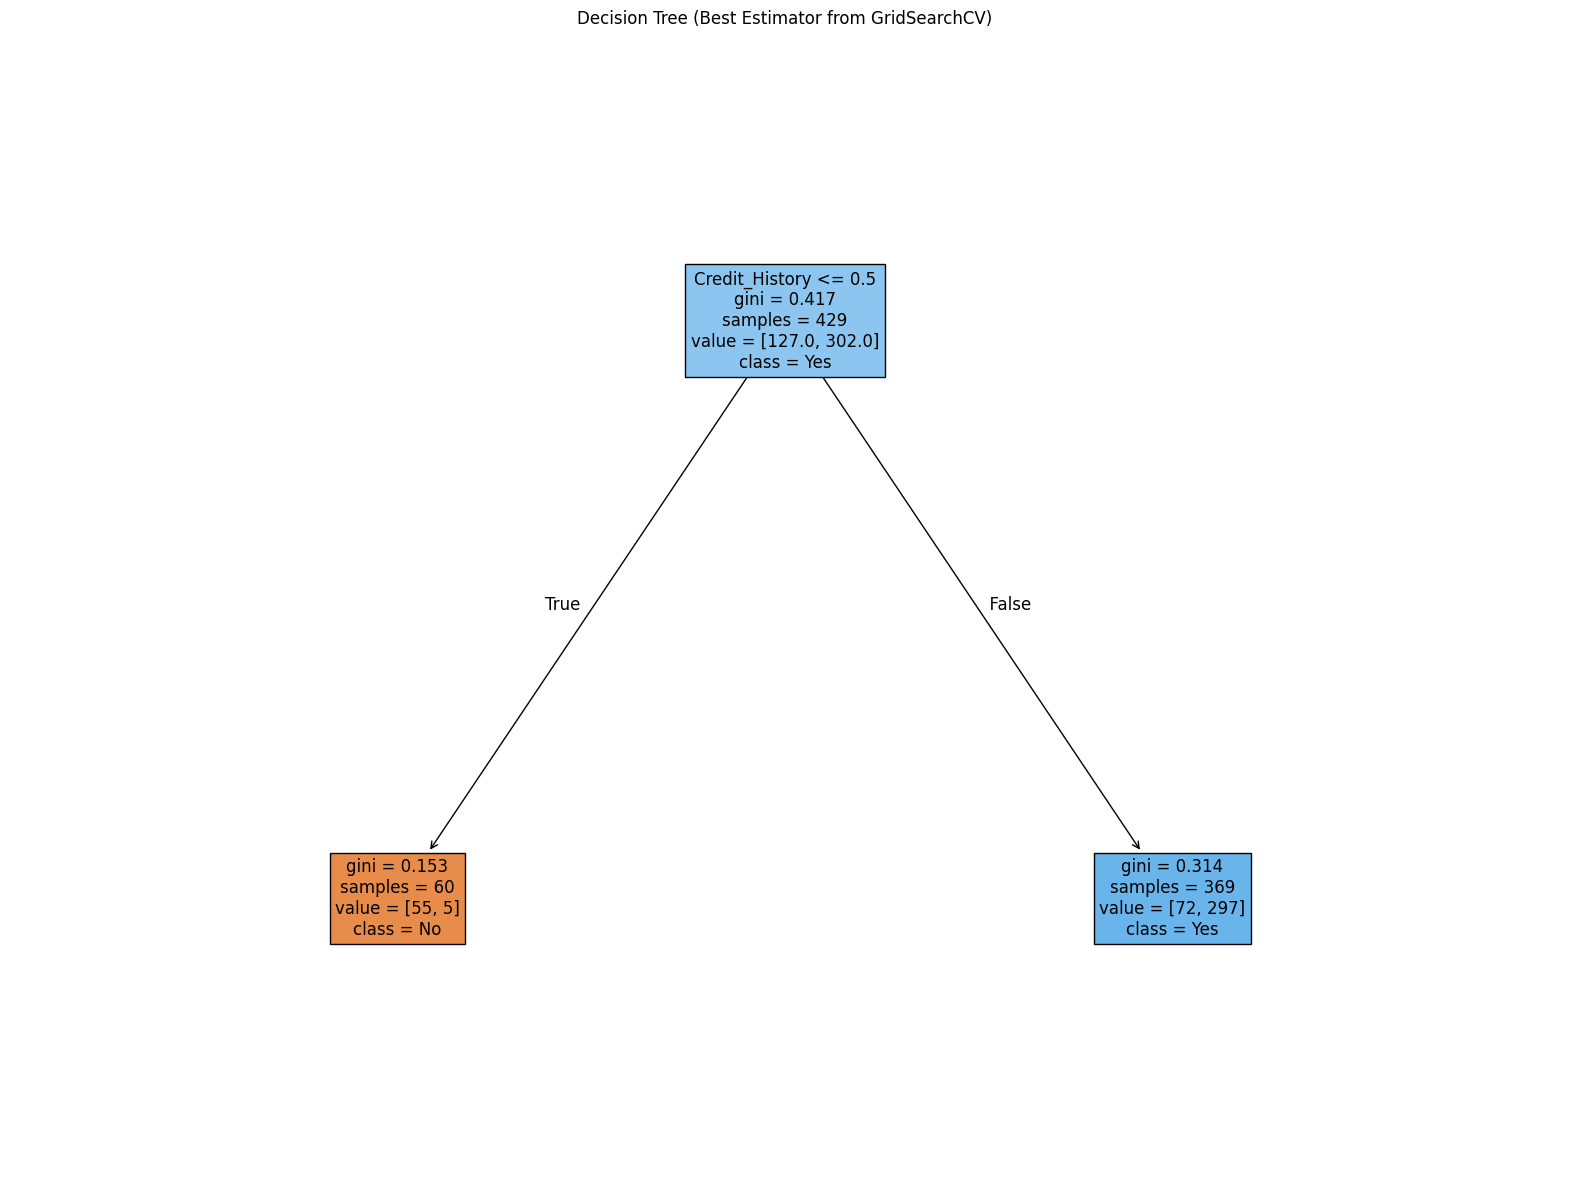

In [219]:
# Tree plot
plt.figure(figsize=(20, 15))
plot_tree(grid_search.best_estimator_, filled=True, fontsize=12, feature_names=list(X.columns), class_names=['No', 'Yes'])
plt.title("Decision Tree (Best Estimator from GridSearchCV)")

# Decision Tree Pruning

##  Why Prune?

- Decision Trees can **overfit** when they grow too deep.  
- Overfitting → very high training accuracy but poor test/generalization accuracy.  
- **Pruning** simplifies the tree by removing branches that do **not contribute much** to prediction.  
- Benefits of pruning:
  - Reduces overfitting  
  - Improves generalization  
  - Makes the tree easier to interpret

---

##  Types of Pruning

### a) Pre-pruning (During Tree Growth)

- Limits the tree **while it is being built**.  
- Stops splitting nodes if they do not meet certain criteria.  
- Common parameters:
  - `max_depth` → maximum depth of the tree  
  - `min_samples_split` → minimum samples required to split a node  
  - `min_samples_leaf` → minimum samples required in a leaf  
- Effect: Prevents the tree from growing too complex upfront.

---

### b) Post-pruning (Cost Complexity Pruning)

- Grow the **full tree first**, then **prune low-importance branches**.  
- Controlled by **`ccp_alpha`**:
  - `ccp_alpha = 0` → no pruning, full tree retained  
  - Higher `ccp_alpha` → more aggressive pruning  
- Principle: Prune branches whose contribution to reducing impurity is small compared to `ccp_alpha`.  
- Effect: Tree becomes simpler without significant loss in accuracy.

---

##  Key Points

- Pre-pruning limits growth early; post-pruning removes unnecessary nodes later.  
- `ccp_alpha` is the main parameter for post-pruning in scikit-learn.  
- Small trees may **not change much** with pruning if there are no low-importance nodes.  
- Always evaluate train/test accuracy to check pruning impact.


In [220]:
alphas = [0, 0.001, 0.005, 0.01, 0.02]

for alpha in alphas:
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    clf.fit(X_train, y_train)
    test_acc = accuracy_score(y_test, clf.predict(X_test))
    print(f"ccp_alpha={alpha}, Test Accuracy={test_acc:.4f}")



ccp_alpha=0, Test Accuracy=0.6811
ccp_alpha=0.001, Test Accuracy=0.6811
ccp_alpha=0.005, Test Accuracy=0.7405
ccp_alpha=0.01, Test Accuracy=0.7838
ccp_alpha=0.02, Test Accuracy=0.7838


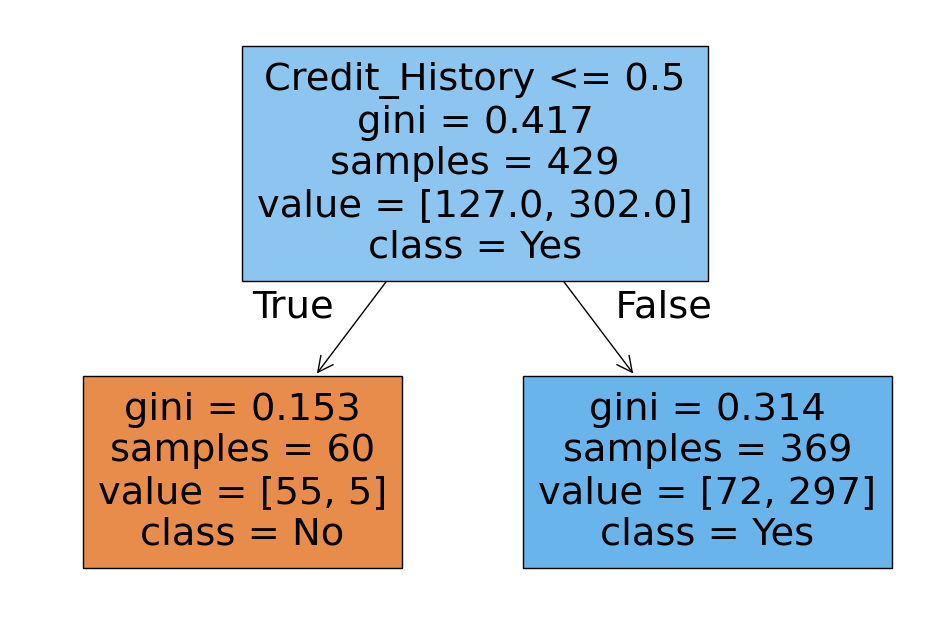

In [221]:
clf_pruned = DecisionTreeClassifier(random_state=42, ccp_alpha=0.01)
clf_pruned.fit(X_train, y_train)

plt.figure(figsize=(12,8))
plot_tree(clf_pruned, feature_names=X_train.columns, class_names=["No","Yes"], filled=True)
plt.show()


## Interpretation

- In this case, the **Decision Tree is already small and shallow**.  
- Applying pruning with `ccp_alpha` **does not change the tree structure** or accuracy.  
- Reason: there are **no low-importance nodes** to remove.  
- Takeaway: Pruning is more useful for **large or complex trees** prone to overfitting.


## Conclusion
- Decision Trees are intuitive and versatile for both classification and regression.
- Proper hyperparameter tuning (max_depth, min_samples_leaf, etc.) is crucial to prevent overfitting or underfitting.
- Evaluation metrics help compare default vs tuned models.
- Feature importance provides insights into which features drive predictions.



In [222]:
df['Loan_Status_Y'].value_counts()

Loan_Status_Y
True     422
False    192
Name: count, dtype: int64

- Total = 614 samples.  
- Class distribution ≈ **Y: 422 / 614 ≈ 68.7%**, **N: 192 / 614 ≈ 31.3%**.  
- This is *moderately imbalanced*: the "Y" class is the majority.


## Stratified train-test split
- The class distribution in the train and test sets matches the original dataset

In [223]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train class %:\n", y_train.value_counts(normalize=True).round(3))
print("Test class %:\n", y_test.value_counts(normalize=True).round(3))


Train class %:
 Loan_Status_Y
True     0.686
False    0.314
Name: proportion, dtype: float64
Test class %:
 Loan_Status_Y
True     0.691
False    0.309
Name: proportion, dtype: float64


In [224]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    "criterion": ["gini", "entropy"],          
    "max_depth": [1, 3, 5, 7, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_leaf_nodes": [None, 5, 10, 20],
}



grid_search.fit(X_train, y_train)
print("Best params:", grid_search.best_params_)
print("CV Accuracy:", grid_search.best_score_)
best_tree = grid_search.best_estimator_


Best params: {'criterion': 'gini', 'max_depth': 1, 'max_leaf_nodes': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
CV Accuracy: 0.7983714698000413


## Cross-Validation in RandomizedSearchCV

When using `RandomizedSearchCV` with `cv=5`, it means 5-fold cross-validation is applied to evaluate each random hyperparameter combination.

### How it works
1. The training set is split into 5 folds (subsets).  
2. For each random hyperparameter setting:
   - Train the model on 4 folds.  
   - Validate on the remaining 1 fold.  
   - Repeat this process 5 times, each time changing the validation fold.  
3. Compute the mean validation score across all 5 folds.  
   - This score is stored in `best_score_`.  
   - The hyperparameters with the highest mean CV score are chosen.  

### Why cross-validation?
- Reduces the risk of overfitting to a single train/validation split.  
- Provides a more reliable estimate of model performance.  
- Ensures all data points are used for both training and validation (just not at the same time).  

---

## Stratified Cross-Validation

For classification tasks, `RandomizedSearchCV` uses Stratified K-Fold by default.  

- **K-Fold**: Splits data into K folds randomly; class distribution can vary.  
- **Stratified K-Fold**: Ensures each fold preserves the same proportion of classes as the full dataset.  

Example: If the dataset has 70% "Yes" and 30% "No", each fold will also have about 70% "Yes" and 30% "No".  

This prevents folds from being unbalanced, which is especially important in imbalanced datasets.  

---

### Key Points
- `n_iter`: number of random hyperparameter combinations tried.  
- `cv=5`: each combination is evaluated with 5-fold CV.  
- `scoring`: metric used to evaluate folds (e.g., `'accuracy'`, `'f1'`, `'roc_auc'`).  
- `best_score_`: average validation score across folds for the best parameters.  
- `best_estimator_`: model retrained on the full training set with the best parameters.  


In [225]:
from sklearn.model_selection import RandomizedSearchCV
param = {
    "criterion": ["gini", "entropy"],         
    "max_depth": [1, 3, 5, 7, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_leaf_nodes": [None, 5, 10, 20],
}

random_search = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_distributions=param,
    n_iter=10,            
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best RandomSearch Parameters:", random_search.best_params_)
print("Best RandomSearch Accuracy:", random_search.best_score_)

Best RandomSearch Parameters: {'min_samples_split': 2, 'min_samples_leaf': 4, 'max_leaf_nodes': 5, 'max_depth': 1, 'criterion': 'gini'}
Best RandomSearch Accuracy: 0.7983714698000413


In [226]:
from sklearn.metrics import accuracy_score

# After random_search.fit(...)
print("CV mean accuracy (validation folds):", random_search.best_score_)

# Best estimator refit on the full training set (because refit=True by default)
best_clf = random_search.best_estimator_

# Training-set accuracy (optional, to check overfitting)
train_acc = accuracy_score(y_train, best_clf.predict(X_train))
print("Train accuracy:", train_acc)

# Test-set accuracy (final, unbiased estimate)
test_acc = accuracy_score(y_test, best_clf.predict(X_test))
print("Test accuracy:", test_acc)


CV mean accuracy (validation folds): 0.7983714698000413
Train accuracy: 0.7983706720977597
Test accuracy: 0.8536585365853658
